#Day 28 Mini Project Regresi End to End: Prediksi Harga Mobil Bekas


Ini adalah **proyek penutup modul regresi**. Kita akan menyatukan semua yang sudah dipelajari menjadi satu alur kerja profesional: dari **data mentah yang berantakan** hingga **model siap pakai** — semuanya dirangkai rapi dengan **`Pipeline`** dan **`ColumnTransformer`** dari scikit-learn.

> 🎯 **Tujuan Pembelajaran**
> - Membersihkan data dunia nyata yang kotor (teks bercampur angka, satuan, dll).
> - Melakukan **feature engineering** (membuat fitur `umur` mobil).
> - Membangun **`Pipeline` + `ColumnTransformer`** untuk encoding & scaling otomatis.
> - Melatih model regresi, mengevaluasi dengan cross-validation, dan menyimpan prediksi.

## Tentang Dataset


**Car Price Prediction Challenge** berisi ribuan iklan mobil bekas lengkap dengan spesifikasi dan harganya. Target kita: **`Price`**.

- **Sumber:** [Kaggle — deepcontractor/car-price-prediction-challenge](https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge)

| Kolom | Catatan |
|-------|---------|
| `Price` | **(Target)** harga mobil |
| `Levy` | pajak; berisi tanda `-` untuk nilai kosong |
| `Prod. year` | tahun produksi → akan diubah jadi **umur** |
| `Engine volume` | berisi teks `Turbo` yang perlu dibersihkan |
| `Mileage` | berisi satuan ` km` yang perlu dihapus |
| `Manufacturer`, `Category`, `Fuel type`, `Gear box type`, ... | fitur kategori |

## Import Library

- **pandas / numpy** → olah & bersihkan data.
- **matplotlib / seaborn** → visualisasi.
- **scikit-learn** → `Pipeline`, `ColumnTransformer`, `OneHotEncoder`, `StandardScaler`,   `RandomForestRegressor`, dan utilitas evaluasi.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Import Dataset

In [3]:
!pip install kaggle
!kaggle datasets download -d deepcontractor/car-price-prediction-challenge
!unzip car-price-prediction-challenge.zip

Dataset URL: https://www.kaggle.com/datasets/deepcontractor/car-price-prediction-challenge
License(s): CC0-1.0
100% 429k/429k [00:00<00:00, 47.1MB/s]

Archive:  car-price-prediction-challenge.zip
  inflating: car_price_prediction.csv  


##Eksplorasi Awal Dataset

In [4]:
df = pd.read_csv('car_price_prediction.csv')
df.head()


,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [5]:
df.info()

print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
print(f'Jumlah data kosong: {df.isna().sum().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,19237.0,4.557654e+07,936591.422799,20746880.0,45698374.0,45772308.0,45802036.0,45816654.0
Price,19237.0,1.855593e+04,190581.269684,1.0,5331.0,13172.0,22075.0,26307500.0
Prod. year,19237.0,2.010913e+03,5.668673,1939.0,2009.0,2012.0,2015.0,2020.0
Cylinders,19237.0,4.582991e+00,1.199933,1.0,4.0,4.0,4.0,16.0
Airbags,19237.0,6.582627e+00,4.320168,0.0,4.0,6.0,12.0,16.0


Interpretasi:
- Banyak kolom "kotor": `Levy` berisi teks `'-'`, `Mileage` ada satuan `'km'`, `Engine volume` kadang ada kata `'Turbo'`. Semua ini harus dibersihkan sebelum modeling.
- Kolom-kolom yang seharusnya angka (`Mileage`, `Engine volume`, `Levy`) terbaca sebagai teks (`object`) karena bercampur karakter. Inilah pekerjaan utama tahap pembersihan.
- Beberapa kolom numerik tersimpan sebagai teks — perlu konversi.

##Cleaning Data

1. `Levy`: ganti `'-'` → 0, jadikan angka.
2. `Mileage`: buang teks `' km'`, jadikan angka.
3. `Engine volume`: buang kata `'Turbo'`, jadikan angka.
4. Buat fitur **`Age`** = tahun sekarang − `Prod. year`.
5. Buang **outlier harga ekstrem** (Price sangat kecil/besar) agar model tidak bias.

In [7]:
data = df.copy()

In [8]:
#1. `Levy`: ganti `'-'` → 0, jadikan angka.
data['Levy'] = pd.to_numeric(data['Levy'].replace('-', 0), errors='coerce').fillna(0)

In [9]:
#2. `Mileage`: buang teks `' km'`, jadikan angka.
data['Mileage'] = pd.to_numeric(
    data['Mileage'].astype(str).str.replace(' km', '', regex=False).str.replace("km","", regex=False),
    errors='coerce')

In [10]:
#3. `Engine volume`: buang kata `'Turbo'`, jadikan angka.
data['Turbo'] = data['Engine volume'].str.contains('Turbo', case=False)
data['Engine volume'] = pd.to_numeric(
    data['Engine volume'].astype(str).str.replace(' Turbo', '', regex=False),
    errors='coerce')

In [11]:
#4. Buat fitur **`Age`** = tahun sekarang − `Prod. year`.
data['Age'] = 2020 - data['Prod. year']

In [12]:
print("Sesudah dikonversi")
data[["Levy", "Mileage", "Engine volume", "Age", "Price"]].dtypes

Sesudah dikonversi


,0
Levy,int64
Mileage,int64
Engine volume,float64
Age,int64
Price,int64


 Ketiga kolom kotor kini bertipe angka, dan kita punya fitur baru `umur`. Tanda `-` pada `Levy` menjadi `NaN` yang akan diisi otomatis oleh pipeline nanti.

In [13]:
# 5. Buang kolom tak berguna untuk model
lw, hg = data['Price'].quantile([0.01, 0.99])
bfr =len(data)
data = data[(data['Price'] >= lw) & (data['Price'] <= hg)]
print(f"Baris sebelum: {bfr}, setelah: {len(data)}")


Baris sebelum: 19237, setelah: 18864


In [14]:
# buang harga tidak masuk akal (< 100 USD)
data = data[data['Price'] >= 100]
print("Rentang harga sekarang: %.0f - %.0f USD" % (data['Price'].min(), data['Price'].max()))

Rentang harga sekarang: 100 - 84675 USD


Interpretasi:
 - Outlier harga ekstrem (mis. mobil seharga 0 atau jutaan dolar karena salah input) dapat merusak model. Membuangnya membuat target lebih realistis.
 - Kolom angka kini bersih. `Model` dibuang karena terlalu banyak
kategori unik (akan meledakkan jumlah kolom saat encoding).
- Membuang 1% harga terendah & tertinggi menghapus iklan tak masuk akal (harga 1 USD atau jutaan USD) yang bisa menyesatkan model.

##Eksplorasi Data Analisis dan Visualisasi Data

### a) Distribusi Harga Mobil atau label Y

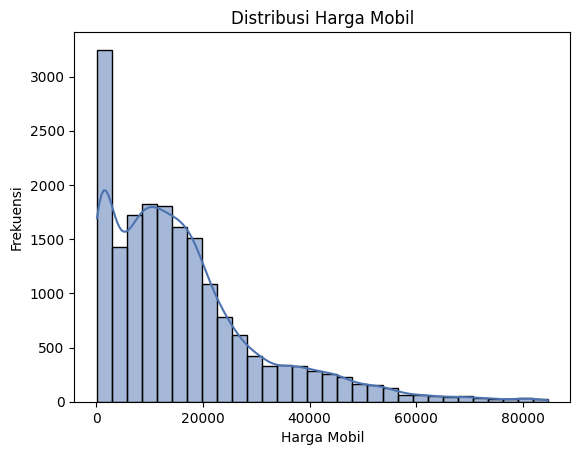

In [15]:
sns.histplot(data=data, x='Price', kde=True, bins=30, color="#4C72B0")
plt.xlabel('Harga Mobil')
plt.ylabel('Frekuensi')
plt.title('Distribusi Harga Mobil')
plt.show()

Interpretasi:
- Right-Skewed ( Distribusi Miring ke Kanan )
- Banyak mobil muraH dan sedikit yang mahal
- Menggambarkan pola umum penjualan mobil bekas

### b) Umur Mobil vs Harga

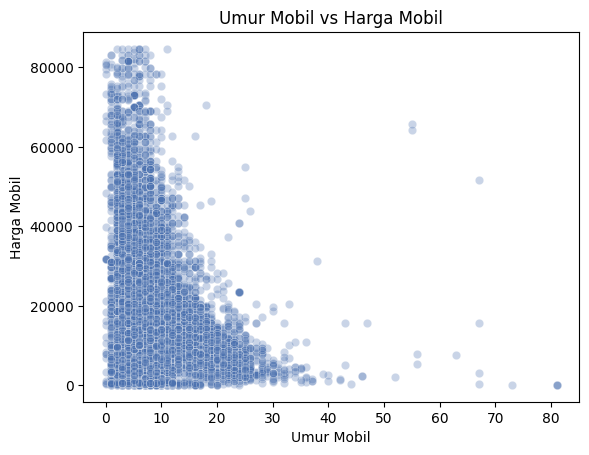

In [16]:
sns.scatterplot(data=data,
                x='Age',
                y='Price',
                color="#4C72B0",
                alpha=0.3)
plt.xlabel('Umur Mobil')
plt.ylabel('Harga Mobil')
plt.title('Umur Mobil vs Harga Mobil')
plt.show()

Interpertasi:
-  Tren terlihat menurun
- Semakin tua mobil, harganya semakin murah
- Hubungam ini tidak sepenuhnya Linear ( Depresiasi Melambat pada monil yang sangat tua atau antik )
- Gunakan modeling berbasih pohon

###c) Harga rata rata berdasarkan tipe bahan bakar

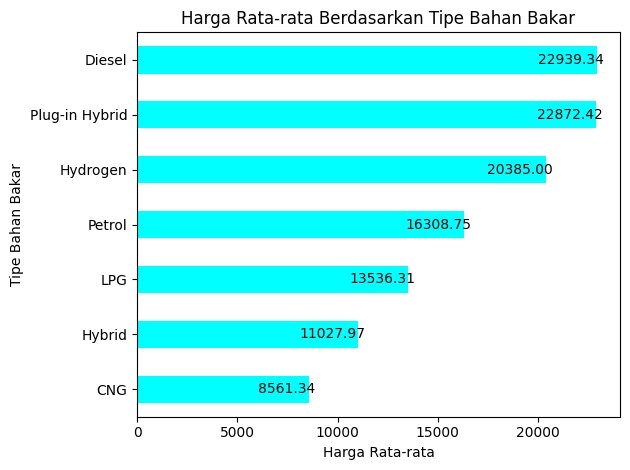

In [17]:
# Hitung rata-rata harga berdasarkan tipe bahan bakar dan urutkan
fuel_stats = data.groupby('Fuel type')['Price'].mean().sort_values()

# Plot grafik batang horizontal
fuel_stats.plot(kind='barh', color="cyan")
plt.xlabel('Harga Rata-rata')
plt.ylabel('Tipe Bahan Bakar')

# Berikan anotasi nilai pada setiap batang secara presisi menggunakan indeks numerik y
for index, value in enumerate(fuel_stats):
    plt.annotate(f'{value:.2f}', (value, index),
                 ha='right',
                 va='center',
                 xytext=(5, 0),
                 textcoords='offset points')

plt.title('Harga Rata-rata Berdasarkan Tipe Bahan Bakar')
plt.tight_layout()
plt.show()

Interpretasi:
- Mobil dengan bahan bakar **Diesel** dan **Plug-in Hybrid** memiliki rata-rata harga tertinggi (di atas 22 ribu USD).
- Mobil berbahan bakar **CNG** memiliki rata-rata harga paling rendah (sekitar 8,5 ribu USD).
- Perbedaan harga ini masuk akal karena teknologi mesin Diesel (yang sering digunakan pada SUV/mobil besar tangguh) dan Hybrid cenderung lebih mahal dibanding mobil berbahan bakar gas (CNG/LPG).
-  Beberapa jenis bahan bakar (mis. Hybrid/Diesel) cenderung berasosiasi dengan harga lebih tinggi. Fitur kategori seperti ini penting, dan akan kita encode otomatis lewat `ColumnTransformer`.

## Menyiapkan Feature dan Target ( X dan y )

Kita pilih sejumlah kolom numerik dan kategori yang  Relevan. `ID`, `Price`, dan `Prod. year` (sudah diwakili `umur`) tidak dipakai sebagai fitur.

In [18]:
fit_num = ["Levy",
           "Engine volume",
           "Mileage",
           "Cylinders",
           "Airbags",
           "Age"]

fit_cat = ["Manufacturer",
           "Category",
           "Leather interior",
           "Fuel type",
           "Gear box type",
           "Drive wheels"]

In [19]:
X = data[fit_num + fit_cat].copy()
y = data["Price"].copy()

In [20]:
# Batasi kategori Manufacturer yang terlalu banyak: kelompokkan yang jarang jadi 'Lain'
top_manf = X['Manufacturer'].value_counts().nlargest(10).index
X['Manufacturer'] = X['Manufacturer'].where(X['Manufacturer'].isin(top_manf), 'Lain')

print("Jumlah Fitur Numerik:", len(fit_num))
print("Jumlah Fitur Kategori:", len(fit_cat))

X.head()

Jumlah Fitur Numerik: 6
Jumlah Fitur Kategori: 6


,Levy,Engine volume,Mileage,Cylinders,Airbags,Age,Manufacturer,Category,Leather interior,Fuel type,Gear box type,Drive wheels
0,1399,3.5,186005,6.0,12,10,LEXUS,Jeep,Yes,Hybrid,Automatic,4x4
1,1018,3.0,192000,6.0,8,9,CHEVROLET,Jeep,No,Petrol,Tiptronic,4x4
2,0,1.3,200000,4.0,2,14,HONDA,Hatchback,No,Petrol,Variator,Front
3,862,2.5,168966,4.0,0,9,FORD,Jeep,Yes,Hybrid,Automatic,4x4
4,446,1.3,91901,4.0,4,6,HONDA,Hatchback,Yes,Petrol,Automatic,Front


Interpretasi:
-   Kita membatasi `Manufacturer` ke 15 merek terbanyak dan menyatukan sisanya jadi 'Lain' agar hasil one-hot encoding tidak meledak jumlah kolomnya.

## Membangun Pipeline - ColumnTransformer

Inti notebook ini. **`ColumnTransformer`** memperlakukan kolom numerik dan kategori secara berbeda:

  - **Numerik** → isi nilai kosong dengan median (`SimpleImputer`) lalu **standardisasi** (`StandardScaler`).
  - **Kategori** → isi kosong dengan modus lalu **one-hot encoding** (`OneHotEncoder`).
  - Kemudian semuanya dibungkus dalam **`Pipeline`** bersama model.

Keuntungannya:
  - seluruhlangkah preprocessing + model menjadi **satu objek** yang konsisten dan anti-bocor data.

In [21]:
prep_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

prep_cat = Pipeline([
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('onehote', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', prep_num, fit_num),
    ('cat', prep_cat, fit_cat),
])

model = Pipeline([
    ('prep', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=1)),
])

model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Levy', 'Engine volume',
                                                   'Mileage', 'Cylinders',
                                                   'Airbags', 'Age']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehote',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Manufacturer', 'Category',
                                                   'Leather interior',
                                                   'Fuel type', 'Gear box type',
                                                   'Drive wheels'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=120, n_jobs=1,
                                       random_state=42))])

Interpretasi:
  - Diagram Pipeline menunjukkan alur:
  data masuk -> `ColumnTransformer` Memproses data numerik & kategorikal -> `RandomForestRegressor` Melatih dan Memprediksi
  -  Semua dijalankan dengan satu `.fit()`

##Bagi Data ( data latih dan data test )

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

## Melatih dan Mengevaluasi Model

In [23]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [24]:
#Evaluasi model dengan Metriks
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)


print(f'MAE: {MAE:.2f}')
print(f'RMSE: {RMSE:.2f}')
print(f'R2: {R2:.2f}')

MAE: 3746.91
RMSE: 6899.54
R2: 0.79


Interpretasi:

  - Akurasi Cukup Baik ($R^2 = 0.79$ atau 79%): Model mampu menjelaskan sekitar 79% variasi harga mobil bekas, yang berarti model ini sudah cukup andal dalam mengenali pola harga di pasaran.
  - Tingkat Kesalahan (MAE = 3,746.91): Secara rata-rata, tebakan harga dari model ini meleset sekitar $3,746 dari harga aslinya di pasaran.
  - Error Besar (RMSE = 6,899.54): Karena nilai RMSE lebih tinggi dari MAE, ini menandakan ada beberapa prediksi mobil yang meleset cukup jauh (biasanya terjadi pada mobil-mobil mewah atau langka yang harganya ekstrem).

### a) Cross-Validation untuk hasil yang lebih stabil

In [27]:
kf = KFold(n_splits=5,
           shuffle=True,
           random_state=42)


neg_mse_score = cross_val_score(model,
                                X,
                                y,
                                cv=kf,
                                scoring='neg_mean_squared_error',
                                n_jobs=1)

mse_scores = -neg_mse_score
rmse_scores = np.sqrt(mse_scores)


In [35]:
# Memformat masing-masing nilai di dalam array terlebih dahulu
#mse_tiap_fold = [f"{score:.2f}" for score in mse_scores]
rmse_tiap_fold = [f"{score:.2f}" for score in rmse_scores]

#print(f'MSE tiap Fold: {mse_tiap_fold}')
print(f'RMSE tiap Fold: {rmse_tiap_fold}')

# Untuk nilai rata-rata (karena bertipe scalar/angka tunggal), kita bisa langsung menggunakan :.2f
print(f'RMSE rata-rata: {rmse_scores.mean():.2f}')
#print(f'MSE rata-rata: {mse_scores.mean():.2f}')

RMSE tiap Fold: ['6880.44', '6990.88', '7104.73', '6620.24', '7182.09']
RMSE rata-rata: 6955.68


Interpretasi:
- Konsisten di Setiap Lipatan Data: Nilai RMSE di setiap fold (berkisar antara 6.620 hingga 7.182) tidak menunjukkan lonjakan yang ekstrem atau berbeda jauh dari angka rata-ratanya (6.955,68).

Artinya: Performa model stabil dan dapat diandalkan, karena tingkat kesalahan prediksinya hampir sama konsistennya saat diuji pada bagian data mobil bekas yang berbeda-beda.

### b) Visualisasi Prediksi vs Aktualisasi

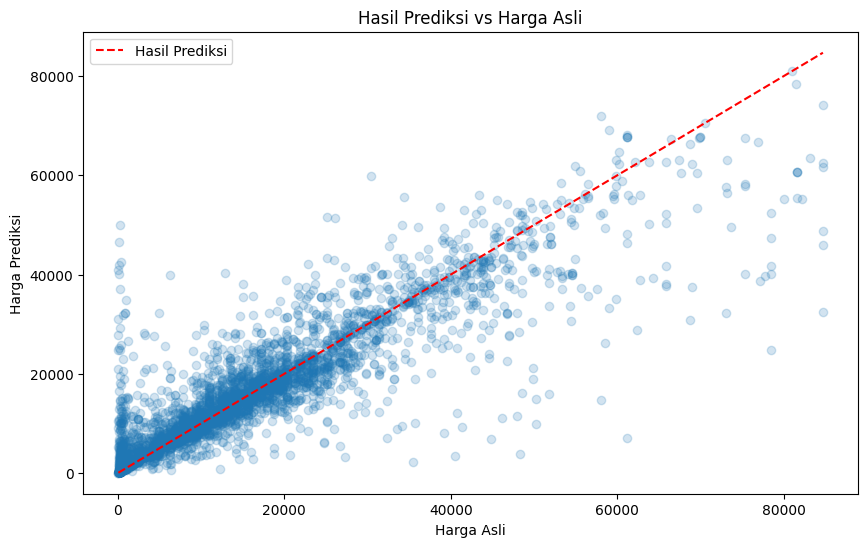

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(y_test,
            y_pred,
            alpha=0.2)

lims = [y_test.min(), y_test.max()]
plt.plot(lims,
         lims,
         "r--",
         label="Hasil Prediksi")

plt.xlabel('Harga Asli')
plt.ylabel('Harga Prediksi')
plt.title('Hasil Prediksi vs Harga Asli')
plt.legend()
plt.show()

Interpretasi:
 - Pola Mendekati Garis Merah: Sebagian besar titik data berkumpul rapi di sekitar garis putus-putus merah, yang menandakan bahwa prediksi model sudah cukup akurat dan mendekati harga aslinya.   

  - Kecenderungan pada Harga Tinggi: Untuk mobil-mobil dengan harga yang lebih mahal (di atas 40.000 ke atas), titik-titiknya mulai menyebar lebih lebar atau berada di bawah garis merah, yang berarti model cenderung sedikit underestimate (menebak lebih rendah dari harga aslinya) pada mobil berharga tinggi.   


## Menyimpan Hasil Prediksi

In [34]:
result_pred = X_test.copy()

result_pred['Harga Asli'] = y_test.values
result_pred['Harga Prediksi'] = np.round(y_pred, 0)
result_pred['Selisih'] = result_pred['Harga Prediksi'] - result_pred['Harga Asli']

# Memperbaiki nama kolom yang diakses agar sesuai dengan yang didefinisikan di atas
result_pred[["Manufacturer", "Age", "Mileage", "Harga Asli", "Harga Prediksi", "Selisih"]].head(10)

,Manufacturer,Age,Mileage,Harga Asli,Harga Prediksi,Selisih
17528,HYUNDAI,4,60604,45210,44297.0,-913.0
667,TOYOTA,6,166560,39201,35929.0,-3272.0
10099,LEXUS,5,143619,13956,13730.0,-226.0
11034,HYUNDAI,5,110000,48403,43896.0,-4507.0
18063,HYUNDAI,4,331445,11290,11784.0,494.0
14803,Lain,2,21328,6586,7628.0,1042.0
3784,Lain,6,117527,32935,34777.0,1842.0
3555,CHEVROLET,5,30000,23678,38178.0,14500.0
9411,TOYOTA,8,164000,15367,10512.0,-4855.0
15195,LEXUS,6,126021,627,1004.0,377.0


Interpretasi:
-  Tabel ini memperlihatkan prediksi model berdampingan dengan harga sebenarnya

- Kolom `Selisih` membantu melihat dimana model tersebut meleset


## Kesimpulan & Insight

- Data dunia nyata sering **kotor**; membersihkannya (satuan, tanda `-`, teks campuran) adalah bagian terbesar pekerjaan.
- **Feature engineering** sederhana seperti `umur` mobil bisa menjadi prediktor kuat.
- **`Pipeline` + `ColumnTransformer`** membuat preprocessing **rapi, konsisten, dan anti-bocor** — encoding & scaling hanya "dipelajari" dari data latih lalu diterapkan ke data uji.
- **Random Forest** menangani campuran fitur numerik & kategori dengan baik dan menghasilkan R² yang layak.
- Membungkus semuanya dalam satu objek pipeline membuat model **mudah dipakai ulang & dideploy**.